# 06 — Transfer Learning

**Goal:** answer a genuinely interesting question — when training data is
scarce, can we do *better* than a from-scratch CNN by starting from a network that already learned
general visual features from millions of ImageNet images, and only fine-tuning a new classifier
head on top of it?

**Concepts applied here:** transfer learning — reusing a pretrained convolutional
base (MobileNetV2, trained on ImageNet) as a fixed feature extractor, then training only a small
new classifier on top.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 1. Load the same `small` image subset used by the from-scratch CNN in Notebook 05

Using the identical small subset (not a new random sample) is what makes this a good
comparison against Notebook 05's from-scratch CNN result.

In [2]:
img_data = joblib.load("../data/processed/image_data.joblib")
X_small, y_small = img_data["image_subsets"]["small"]
X_val, y_val = img_data["X_val"], img_data["y_val"]
class_names = img_data["class_names"]

print("Small training set:", X_small.shape)

Small training set: (1000, 32, 32, 3)


## 2. Resize images for MobileNetV2

Pretrained ImageNet models expect larger inputs than CIFAR-10's native 32×32 (MobileNetV2's
minimum is 96×96). We resize on the fly using a `Resizing` layer built into the model, and use
MobileNetV2's own `preprocess_input` to match the normalization it was trained with.

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 96

def build_transfer_model(num_classes=10, fine_tune_last_n=0):
    base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
    base_model.trainable = False
    if fine_tune_last_n > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-fine_tune_last_n]:
            layer.trainable = False

    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = layers.Rescaling(2.0, offset=-1.0)(x)     # CIFAR pixels are already [0,1]; this rescales to what MobileNetV2 expects
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model

model, base_model = build_transfer_model()
print(f"Trainable params: {sum(np.prod(w.shape) for w in model.trainable_weights):,}")
print(f"Frozen (pretrained) params: {sum(np.prod(w.shape) for w in base_model.weights):,}")

Trainable params: 12,810
Frozen (pretrained) params: 2,257,984


## 3. Train — only the new classifier head is trainable

The pretrained convolutional base stays frozen. We're only learning a small number of new
parameters (the `Dense` head), which is exactly why this works so well with little data — most of
the "knowledge" (edge/texture/shape detectors) is already baked into the frozen weights.

In [4]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

t0 = time.time()
history_frozen = model.fit(
    X_small, y_small,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)
train_time_frozen = time.time() - t0

val_loss, val_acc_frozen = model.evaluate(X_val, y_val, verbose=0)
print(f"Frozen-base transfer learning: val_accuracy={val_acc_frozen:.3f}, time={train_time_frozen:.1f}s")

Frozen-base transfer learning: val_accuracy=0.798, time=191.3s


## 4. Fine-tune the top layers of the pretrained base

After the new head has learned something reasonable, we can unfreeze the *last few* layers of the
pretrained base and continue training with a much smaller learning rate, letting the model adapt
its highest-level features slightly to CIFAR-10 specifically.

In [5]:
model_ft, base_model_ft = build_transfer_model(fine_tune_last_n=20)
model_ft.set_weights(model.get_weights())   # start from the already-trained head
model_ft.compile(optimizer=keras.optimizers.Adam(1e-5),   # much smaller LR for fine-tuning
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
history_finetune = model_ft.fit(
    X_small, y_small,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)
train_time_finetune = train_time_frozen + (time.time() - t0)

val_loss_ft, val_acc_finetune = model_ft.evaluate(X_val, y_val, verbose=0)
print(f"Fine-tuned transfer learning: val_accuracy={val_acc_finetune:.3f}, time={train_time_finetune:.1f}s")

Fine-tuned transfer learning: val_accuracy=0.799, time=278.3s


## 5. Compare: from-scratch CNN vs. frozen transfer learning vs. fine-tuned transfer learning

All three were trained/evaluated on the **exact same small training subset and validation set**.

In [6]:
cnn_results = pd.read_csv("../results/cnn_metrics.csv")
scratch_small_acc = cnn_results.loc[
    (cnn_results["model"] == "CNN_from_scratch") & (cnn_results["dataset_size_name"] == "small"),
    "val_accuracy"
].values[0]

comparison = pd.DataFrame({
    "approach": ["CNN from scratch", "Transfer learning (frozen base)", "Transfer learning (fine-tuned)"],
    "val_accuracy": [scratch_small_acc, val_acc_frozen, val_acc_finetune],
})
comparison.to_csv("../results/transfer_learning_comparison.csv", index=False)
comparison

,approach,val_accuracy
0,CNN from scratch,0.1348
1,Transfer learning (frozen base),0.7978
2,Transfer learning (fine-tuned),0.7994


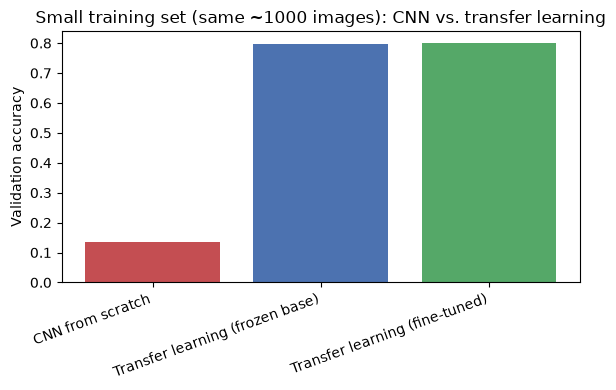

In [7]:
plt.figure(figsize=(6,4))
plt.bar(comparison["approach"], comparison["val_accuracy"], color=["#C44E52", "#4C72B0", "#55A868"])
plt.ylabel("Validation accuracy")
plt.title("Small training set (same ~1000 images): CNN vs. transfer learning")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../results/figures/transfer_learning_comparison.png", dpi=150)
plt.show()

## Summary

On the same small image training set, we compare a from-scratch CNN against transfer learning with
a frozen pretrained base, and against a fine-tuned version.